## Problem Statement

You are a data scientist at a retail consulting firm. You have been provided with a dataset named **"retail_store_sales_data.csv"**, which includes detailed records of daily sales for a retail store over a two-year period. The dataset comprises the following columns:

- **date:** The specific date for each sales record.
- **day_of_week:** The day of the week corresponding to each date.
- **sales_amount (usd):** : The total sales amount in USD recorded on each day.

**Import Necessary Libraries**

In [4]:
import pandas as pd
import numpy as np
import scipy.stats as st
from matplotlib import pyplot as plt
import seaborn as sns

### Task1: Data Import

1. Import the data from the "retail_store_sales_data.csv" file.
2. display the number of rows and columns. 
3. Display the first few rows of the dataset to get an overview.


In [7]:
df=pd.read_csv("retail_store_sales_data.csv")
df.shape
df.head()

,date,day_of_week,sales_amount (usd)
0,01-01-2020,Wednesday,1212
1,02-01-2020,Thursday,1261
2,03-01-2020,Friday,596
3,04-01-2020,Saturday,696
4,05-01-2020,Sunday,1434


### Task2: Histogram Plot of Sales Amounts

- Create the histogram plot for the 'sales_amount (usd)' column

<Axes: xlabel='sales_amount (usd)', ylabel='Count'>

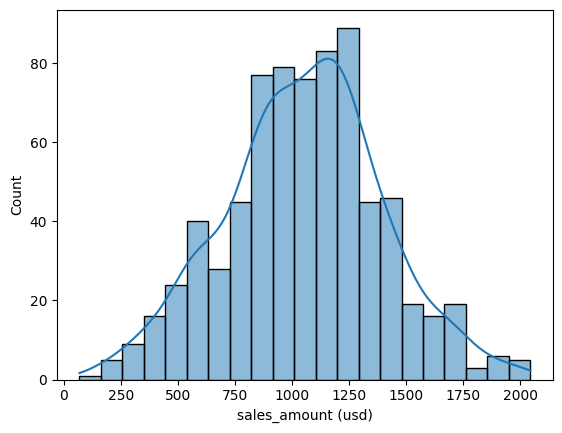

In [11]:
sns.histplot(df["sales_amount (usd)"],kde=True)

### Task 3: Computing Population Standard Deviation

- **Determine Standard Deviation:** Calculate the population standard deviation for the 'Sales_Amount (usd)' column. This is helpful in the accurate creation of confidence intervals in subsequent analyses.

In [14]:
mean_population=df["sales_amount (usd)"].mean()
std_population=df["sales_amount (usd)"].std()
mean_population,std_population

(np.float64(1051.7154582763337), np.float64(344.80896600101187))

### Task4: Create Sample Data

- Create a sample dataset consisting of 100 data points from the 'Sales_Amount (usd)' column.
- Calculate the mean for this sample. 


In [20]:
SAMPLE_SIZE=100
sample=df.sample(SAMPLE_SIZE,random_state=100)
sample.head()

,date,day_of_week,sales_amount (usd)
184,03-07-2020,Friday,846
535,19-06-2021,Saturday,970
299,26-10-2020,Monday,925
221,09-08-2020,Sunday,709
152,01-06-2020,Monday,1163


In [21]:
mean_sample=sample["sales_amount (usd)"].mean()
std_sample=sample["sales_amount (usd)"].std()
mean_sample,std_sample

(np.float64(987.67), np.float64(343.4354380389568))

### Task 5: Estimating Population Mean at Various Confidence Levels

Confidence Interval Calculations: Using the sample data, estimate the population mean for 'Sales_Amount (usd)' at different confidence levels. Specifically, calculate the confidence intervals for the population mean at the following levels:

    - 60% Confidence Level
    - 82% Confidence Level
    - 98% Confidence Level

- **60% Confidence Level**

In [29]:
zscore_60_confidence=st.norm.ppf(0.80)
zscore_60_confidence
margin_of_error=zscore_60_confidence*((std_population)/np.sqrt(SAMPLE_SIZE))
margin_of_error

upper=mean_sample + margin_of_error
lower=mean_sample - margin_of_error
lower, upper 

(np.float64(958.6501452687227), np.float64(1016.6898547312773))

- **82% Confidence Level**

In [33]:
zscore_82_confidence=st.norm.ppf(0.91)
zscore_82_confidence
margin_of_error=zscore_82_confidence * (std_population)/np.sqrt(SAMPLE_SIZE)

upper = mean_sample + margin_of_error
lower=mean_sample - margin_of_error
lower, upper 

(np.float64(941.4395643172625), np.float64(1033.9004356827375))

- **98% Confidence Level**

In [36]:
z_value=(98 + (100-98)/2)/100

zscore_confidence=st.norm.ppf(z_value)
zscore_confidence
margin_of_error=zscore_confidence * (std_population)/np.sqrt(SAMPLE_SIZE)

upper = mean_sample + margin_of_error
lower=mean_sample - margin_of_error
lower, upper 

(np.float64(907.4554394993326), np.float64(1067.8845605006675))